# Influence of rank deficiency
One matrix of rank $r < \min(m, n)$: the error against Sgn(M), the number of iterations to reach `eps` for each D, and the numerical rank of $X_k$ along the orbit. Each iterate is frozen once its error reaches `eps`, and the error and rank are held until `k_max`, so rounding noise in the null space is not amplified. Keep `eps` above the noise floor (about $u/\sigma_{\min}$), otherwise the freeze never fires. Change `rank` or `smin` and rerun.

In [1]:
import sys
sys.path.insert(0, "..")  # repo root, so ns_core and experiments import

import matplotlib.pyplot as plt
import torch

from ns_core import orbit_tools, plots
from experiments.rank_deficiency import RankDeficiencyConfig, run_rank_deficiency
%matplotlib inline

In [4]:
cfg = RankDeficiencyConfig(
    m=128, n=128, rank=32, smin=1e-2, degrees=[1, 2, 3, 4],
    k_max=40,      # steps run at most
    eps=1e-10,     # freeze the iterate once its error reaches this; keep above the noise floor (about u / smin)
    rank_tol=None, # cutoff for a "zero" singular value in the rank plot; None = eps
    dtype=torch.float64, device="cpu", seed=0,
)
res = run_rank_deficiency(cfg)

D=1: 16 iterations
D=2: 11 iterations
D=3: 9 iterations
D=4: 7 iterations


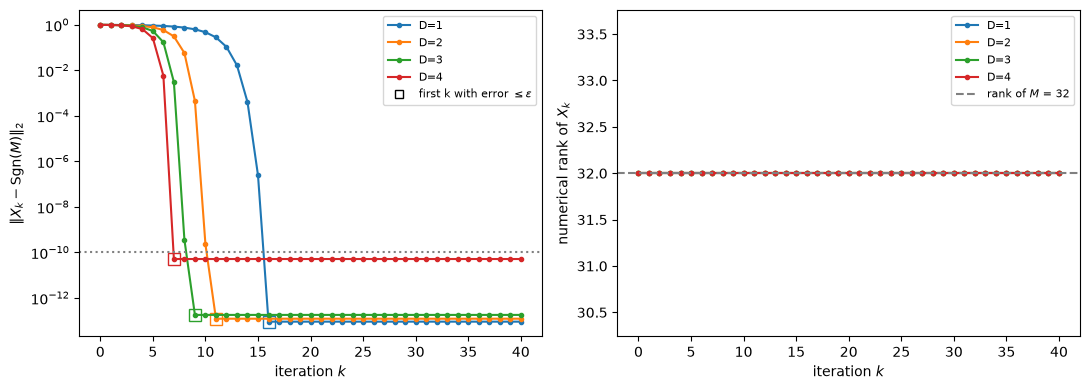

In [5]:
orbit_tools.report_iterations(res["iterations"])
fig, axs = plt.subplots(1, 2, figsize=(11, 4))
plots.plot_error_curves(res["error"], ax=axs[0], eps=cfg.eps)
plots.plot_ranks(res["rank"], r=orbit_tools.resolve_rank(cfg.m, cfg.n, cfg.rank), ax=axs[1])
fig.tight_layout()